# Unit 2: 数据流解析与格式处理

## 学习目标
- 理解 OpenBCI Cyton 二进制数据包的完整结构
- 掌握 24 位有符号 ADC 值的解析与电压缩放方法
- 实现从原始字节流到电压值的完整转换流水线
- 学会解析辅助数据（加速度计/时间戳）
- 能够将采集数据保存为标准格式（CSV）

## 核心概念

### 数据包结构（33 字节）

```text
Byte 1      : 0xA0        起始字节
Byte 2      : sample id   样本编号
Byte 3-26   : EEG 数据     8 通道 × 3 字节
Byte 27-32  : AUX 数据     6 字节
Byte 33     : 0xCX        结束字节
```

每个数据包由以下部分组成（详见 [Cyton Data Format](https://docs.openbci.com/Cyton/CytonDataFormat/)）：

| 字节位置 | 长度 | 内容 | 说明 |
|---------|------|------|------|
| 0 | 1 | 起始字节 | 固定为 `0xA0` |
| 1 | 1 | 采样序号 | 0-255 循环计数 |
| 2-25 | 24 | EEG 数据 | 8 通道 x 3 字节/通道，24-bit 有符号，MSB 优先 |
| 26-31 | 6 | 辅助数据 | 加速度计 (3 轴 x 2 字节) 或用户自定义 |
| 32 | 1 | 结束字节 | `0xC0`-`0xCF`（含格式化信息） |

### 电压缩放公式
ADS1299 的 24 位 ADC 值需转换为微伏（uV）：

```text
scale_factor = (Vref * 1000000) / (gain * (2^23 - 1))
voltage_uV = raw_adc_value * scale_factor
```

其中：
- `Vref` = 4.5V（ADS1299 参考电压）
- `gain` = 24（默认增益，可配置为 1, 2, 4, 6, 8, 12, 24）
- `2^23 - 1` = 8388607（24 位有符号最大值）
- 默认增益 24 时，scale_factor ≈ 0.02235 uV/LSB

### 24 位有符号整数解析
由于 Python 没有原生 24 位整数类型，需手动处理符号位：
```text
raw = (byte0 << 16) | (byte1 << 8) | byte2
if raw >= 0x800000:  # 检查符号位
    raw -= 0x1000000  # 转换为负数
```

## 1. 环境准备与基础工具函数

In [49]:
# 标准库导入：按字母顺序排列
import os
import struct
import time
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

# 第三方库导入：按字母顺序排列
import numpy as np
import pandas as pd


print("Modules imported successfully.")

Modules imported successfully.


关于加速度计的缩放因子  
OpenBCI 文档说明 Cyton 默认按 ±4g 量程处理，LIS3DH 在这个量程下灵敏度是 2 mg/digit = 0.002 g/digit，所以公式里先有 0.002。  
但是，LIS3DH 的数据寄存器通常读出来是 16 bit，但在高分辨率模式下有效数据并不是完整 16 bit，而是 12 bit 左对齐。  
也就是说，真正有意义的 12 位数据放在高 12 位，低 4 位只是填充位。ST 社区资料也提到 LIS3DH 的 12 位数据是 left justified。  
所以，原始加速度计整数值每变化 1 个 count，对应 0.000125 g。  
即0.002/(2>>4) = 0.000125 g/LSB

In [ ]:
# ==================== 常量定义 ====================

# ADS1299 参考电压（伏特）
ADS1299_VREF = 4.5

# 24 位 ADC 最大值
ADC_24BIT_MAX = (2 ** 23) - 1  # 8388607

# 默认增益
DEFAULT_GAIN = 24

# 默认电压缩放因子（微伏/LSB）
DEFAULT_SCALE = (ADS1299_VREF * 1_000_000) / (DEFAULT_GAIN * ADC_24BIT_MAX)
print(f"Default scale factor: {DEFAULT_SCALE:.6f} μV/LSB")

# 加速度计缩放因子
# 16 bit 原始值:
# xxxx xxxx xxxx 0000
#                ↑
#          低 4 位不是有效精度
# acc_g = (raw >> 4) * 0.002
LIS3DH_SCALE = 0.002 / (2 ** 4)  # 0.002g / 16 = 0.000125 g/LSB
print(f"Accelerometer scale factor: {LIS3DH_SCALE} g/LSB")

Default scale factor: 0.022352 uV/LSB
Accelerometer scale factor: 0.000125 g/LSB


## 2. 数据包解析核心函数

In [3]:
def parse_24bit_signed(eeg_counts: bytes) -> int:
    """
    将 3 字节解析为 24 位有符号整数
    
    ADS1299 数据格式：MSB 优先（大端序）
    例如: b'\x00\x80\x00' 表示中间范围的值
    
    Args:
        eeg_counts: 3 字节的原始数据
    
    Returns:
        int: 解析后的 24 位有符号整数（范围: -8388608 ~ 8388607）
    """
    if len(eeg_counts) != 3:
        raise ValueError(f"Expected 3 bytes, got {len(eeg_counts)}")
    
    # # 大端序组合 3 字节
    # raw = (eeg_counts[0] << 16) | (eeg_counts[1] << 8) | eeg_counts[2]
    
    # # 如果最高位是 1，说明是负数，需要做符号扩展
    # if raw >= 0x800000:  # 0x800000 = 2^23
    #     raw -= 0x1000000  # 0x1000000 = 2^24，转换为负数

    # 大端序组合 3 字节
    eeg_values = int.from_bytes(eeg_counts, byteorder='big', signed=True)
    return eeg_values


def adc_to_microvolts(eeg_values: int, gain: int = DEFAULT_GAIN) -> float:
    """
    将 ADC 原始值转换为微伏（uV）
    
    转换公式：
        voltage_uV = raw * (Vref * 1e6) / (gain * (2^23 - 1))
    
    Args:
        eeg_values: 24 位有符号 ADC 值
        gain: ADS1299 增益设置（1, 2, 4, 6, 8, 12, 24）
    
    Returns:
        float: 电压值，单位微伏
    """
    scale = (ADS1299_VREF * 1_000_000) / (gain * ADC_24BIT_MAX)
    eeg_microvolts = eeg_values * scale
    return eeg_microvolts


def parse_aux_data(aux_counts: bytes) -> Dict[str, float]:
    """
    解析 6 字节辅助数据为三轴加速度值
    
    格式：AX(2字节) AY(2字节) AZ(2字节)，16-bit 有符号，大端序
    
    Args:
        aux_counts: 6 字节辅助数据
    
    Returns:
        dict: {'ax': float, 'ay': float, 'az': float}，单位 g
    """
    if len(aux_counts) != 6:
        raise ValueError(f"Expected 6 bytes, got {len(aux_counts)}")
    
    # 使用 struct 解包 3 个大端序 16 位有符号整数
    # >  大端序
    # h  16-bit signed short，有符号 16 位整数
    # h  16-bit signed short
    # h  16-bit signed short
    ax_raw, ay_raw, az_raw = struct.unpack('>hhh', aux_counts)
    
    # 感器原始整数值转换成真实加速度单位 g
    return {
        'ax': ax_raw * LIS3DH_SCALE,
        'ay': ay_raw * LIS3DH_SCALE,
        'az': az_raw * LIS3DH_SCALE
    }


# 测试解析函数
test_raw = b'\x00\x01\x00'  # 256
print(f"24-bit parse test: {parse_24bit_signed(test_raw)}")

test_negative = b'\xFF\xFF\xFF'  # -1
print(f"24-bit parse test (negative): {parse_24bit_signed(test_negative)}")

print(f"ADC to uV test: {adc_to_microvolts(1000):.4f} uV")

24-bit parse test: 256
24-bit parse test (negative): -1
ADC to uV test: 22.3517 uV


## 3. 完整数据包解析器

In [18]:
@dataclass
class EEGSample:
    """
    存储单个采样点的数据
    
    Attributes:
        sample_number: 采样序号（0-255 循环）
        eeg_data: 8 通道 EEG 电压值（单位：微伏μV）
        aux_data: 辅助数据（加速度计三轴，单位：g）
        stop_byte: 数据包结束字节
        timestamp: 采样时间戳（秒）
    """
    sample_number: int
    eeg_data: List[float]
    aux_data: Dict[str, float]
    stop_byte: int
    timestamp: float


def parse_cyton_packet(packet: bytes, gain: int = DEFAULT_GAIN) -> Optional[EEGSample]:
    """
    解析单个 Cyton 数据包（33 字节）
    
    串口读出的原始数据包（33 字节）布局如下：
        [0]     : 起始字节 (0xA0)
        [1]     : 采样序号
        [2:26]  : 8 通道 EEG 数据（每通道 3 字节）
        [26:32] : 辅助数据（6 字节）
        [32]    : 结束字节 (0xC0 ~ 0xCF)
                    0xC0 : Standard with accel
                    0xC1 : Standard with raw aux
                    0xC2 : User defined
                    0xC3 : Time stamped set with accel
                    0xC4 : Time stamped with accel
                    0xC5 : Time stamped set with raw aux
                    0xC6 : Time stamped with raw aux
        结束字节不只是结束标志，它还告诉你 [26:32] 这 6 字节辅助数据应该怎么解释。
        官方文档也强调，driver 应该使用 stop byte 判断 AUX 字节的解析方式。
    
    Args:
        packet: 33 字节原始数据包
        gain: ADS1299 增益值
    
    Returns:
        EEGSample 对象，解析失败返回 None
    """
    PACKET_SIZE = 33
    START_BYTE = 0xA0
    STOP_BYTE_PREFIX = 0xC0  # 结束字节前4个字节的前缀
    
    # 验证数据包长度
    if len(packet) != PACKET_SIZE:
        print(f"Warning: Expected {PACKET_SIZE} bytes, got {len(packet)}")
        return None
    
    # 验证起始字节
    if packet[0] != START_BYTE:
        print(f"Warning: Invalid start byte 0x{packet[0]:02X} (expected 0xA0)")
        return None
    
    # 验证结束字节前缀
    if (packet[32] & 0xF0) != STOP_BYTE_PREFIX:
        print(f"Warning: Invalid stop byte prefix 0x{packet[32]:02X} (expected 0xC0-0xCF)")
        return None

        
    # ----------------- 开始解析数据包 -----------------
    # 提取采样序号
    sample_number = packet[1]
    
    # 存储 8 通道 EEG 电压值（单位：微伏）
    eeg_data: List[float] = []
    for ch in range(8):
        # 每通道占 3 字节
        start_idx = 2 + ch * 3
        end_idx = start_idx + 3
        eeg_count = packet[start_idx:end_idx]               # adc count
        eeg_value = parse_24bit_signed(eeg_count)           # 解析为 24 位有符号整数
        eeg_microvolt = adc_to_microvolts(eeg_value, gain)  # 还原为微伏
        eeg_data.append(eeg_microvolt)
    
    # 提取xyz轴加速度计值（单位：g）
    aux_counts = packet[26:32]
    aux_data: Dict[str, float] = parse_aux_data(aux_counts)
    
    # 提取结束字节
    stop_byte = packet[32]
    
    return EEGSample(
        sample_number=sample_number,
        eeg_data=eeg_data,
        aux_data=aux_data,
        stop_byte=stop_byte,
        timestamp=time.time() # 使用系统时间戳作为采样时间戳
    )


# 模拟 cyton 生成数据包
def create_mock_packet(sample_num: int = 0, 
                       eeg_values: Optional[List[int]] = None,
                       aux_values: Optional[List[int]] = None,
                       stop_byte: int = 0xC0) -> bytes:
    """
    创建模拟数据包（用于测试，无需真实硬件）
    
    Args:
        sample_num: 采样序号
        eeg_values: 8 个 24 位 ADC 值（可选）
        aux_values: 3 个 16 位 AUX 值（可选）
        stop_byte: 结束字节
    
    Returns:
        bytes: 33 字节数据包
    """
    if eeg_values is None:
        eeg_values = [0] * 8
    if aux_values is None:
        aux_values = [0] * 3

    # bytearray 类型是可变的字节序列
    packet = bytearray()  
    packet.append(0xA0)
    packet.append(sample_num & 0xFF)
    
    # 8 个 24 位 ADC 值
    for value in eeg_values:
        # 处理负数：转换为 24 位补码
        if value < 0:
            value = value + 0x1000000
        packet.append((value >> 16) & 0xFF)
        packet.append((value >> 8) & 0xFF)
        packet.append(value & 0xFF)
    
    # 3 个 16 位 AUX 值
    for value in aux_values:
        if value < 0:
            value = value + 0x10000
        packet.append((value >> 8) & 0xFF)
        packet.append(value & 0xFF)
    
    packet.append(stop_byte & 0xFF)
    
    # 转换为 bytes 类型，是不可变的字节序列
    return bytes(packet)  

# 测试 1: 全零数据包
mock_pkt = create_mock_packet(sample_num=1)
sample = parse_cyton_packet(mock_pkt)
if sample:
    print("=== Testing Mock Packet 1 ===")
    print(f"{'sample_number':<15} {sample.sample_number}")
    print(f"{'eeg_data':<15} {[f'{v:.4f}μV' for v in sample.eeg_data]}")
    print(f"{'aux_data':<15} {sample.aux_data}(g)")
    print(f"{'stop_byte':<15} 0x{sample.stop_byte:02X}")
    print(f"{'timestamp':<15} {sample.timestamp}")


# 测试 2: 带有特定值的数据包
test_eeg_values = [1000, -500, 2000, 0, 3000, -1000, 500, 1500]  # ADC 原始值
test_aux_values = [100, -200, 300]  # AUX 原始值
mock_pkt2 = create_mock_packet(sample_num=2, eeg_values=test_eeg_values, aux_values=test_aux_values)    
sample2 = parse_cyton_packet(mock_pkt2)
if sample2:
    print("===Test Mock Packet 2 ===")
    print(f"{'sample_number':<15} {sample2.sample_number}")
    print(f"{'eeg_data':<15} {[f'{v:.4f}μV' for v in sample2.eeg_data]}")
    print(f"{'aux_data':<15} {sample2.aux_data}(g)")
    print(f"{'stop_byte':<15} 0x{sample2.stop_byte:02X}")
    print(f"{'timestamp':<15} {sample2.timestamp}")


=== Testing Mock Packet 1 ===
sample_number   1
eeg_data        ['0.0000μV', '0.0000μV', '0.0000μV', '0.0000μV', '0.0000μV', '0.0000μV', '0.0000μV', '0.0000μV']
aux_data        {'ax': 0.0, 'ay': 0.0, 'az': 0.0}(g)
stop_byte       0xC0
timestamp       1778597064.7652614
===Test Mock Packet 2 ===
sample_number   2
eeg_data        ['22.3517μV', '-11.1759μV', '44.7035μV', '0.0000μV', '67.0552μV', '-22.3517μV', '11.1759μV', '33.5276μV']
aux_data        {'ax': 0.0125, 'ay': -0.025, 'az': 0.0375}(g)
stop_byte       0xC0
timestamp       1778597064.7652614


## 4. 数据流采集器

从串口持续读取数据包并转换为结构化数据。

In [56]:
class EEGStreamCollector:
    """
    EEG 数据流采集与缓存类:代码层缓存
    
    功能：
    - 持续从串口读取并解析数据包
    - 维护固定大小的环形缓冲区
    - 提供数据导出功能
    """
    
    def __init__(self, max_samples: int = 1000, gain: int = DEFAULT_GAIN):
        """
        Args:
            max_samples: 最大缓存样本数
            gain: ADS1299 增益值
        """
        self.max_samples = max_samples
        self.gain = gain
        self.samples: List[EEGSample] = []
        self.packet_count = 0
        self.parse_errors = 0
    
    def add_sample(self, sample: EEGSample):
        """
        添加样本到缓冲区
        超过最大容量时移除最旧样本（FIFO）
        """
        self.samples.append(sample)
        self.packet_count += 1
        if len(self.samples) > self.max_samples:
            self.samples.pop(0)
    
    def get_numpy_array(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        将缓存数据转换为 NumPy 数组
        
        Returns:
            eeg_array: (N, 8) EEG 电压矩阵，单位 μV
            timestamps: (N,) 时间戳数组
        """
        if not self.samples:
            return np.empty((0, 8)), np.empty(0)
        
        eeg_array = np.array([s.eeg_data for s in self.samples]) # shape (N, 8)
        timestamps = np.array([s.timestamp for s in self.samples]) # shape (N,)
        return eeg_array, timestamps
    
    def get_dataframe(self) -> pd.DataFrame:
        """
        将缓存数据转换为 pandas DataFrame
        
        Returns:
            DataFrame 包含所有通道数据、时间戳和辅助数据
        """
        if not self.samples:
            return pd.DataFrame()
        
        records = []
        for s in self.samples:
            record = {}
            record['timestamp'] = s.timestamp
            record['sample_num'] = s.sample_number
            for i, v in enumerate(s.eeg_data):
                record[f'CH{i+1}_μV'] = v
            record['ax_g'] = s.aux_data['ax']
            record['ay_g'] = s.aux_data['ay']
            record['az_g'] = s.aux_data['az']
            records.append(record)
        
        return pd.DataFrame(records)
    
    def save_to_csv(self, filepath: str):
        """
        将缓存数据保存为 CSV 文件
        
        Args:
            filepath: 输出文件路径
        """
        df = self.get_dataframe()
        if df.empty:
            print("Warning: No data to save.")
            return
        df.to_csv(filepath, index=False)
        print(f"Saved {len(df)} samples to {filepath}")
    
    def get_statistics(self) -> Dict:
        """
        获取数据统计信息
        """
        if not self.samples:
            return {}
        
        eeg_array, _ = self.get_numpy_array()
        stats = {
            'total_packets': self.packet_count,
            'cached_samples': len(self.samples),
            'parse_errors': self.parse_errors,
            'duration_sec': self.samples[-1].timestamp - self.samples[0].timestamp,
            'channels': {}
        }
        
        for i in range(8):
            ch_data = eeg_array[:, i] # 通道i的所有数据
            stats['channels'][f'CH{i+1}'] = {
                'mean_μV': float(np.mean(ch_data)),       # 平均值
                'std_μV': float(np.std(ch_data)),         # 标准差
                'min_μV': float(np.min(ch_data)),         # 最小值
                'max_μV': float(np.max(ch_data)),         # 最大值
                'peak_to_peak_μV': float(np.ptp(ch_data)) # 峰-峰范围：最大值-最小值
            }
        
        return stats
    
    def clear(self):
        """清空缓存"""
        self.samples.clear()

## 5. 实践：使用模拟数据进行完整处理流水线

In [57]:
# 创建采集器实例:代码层缓存
collector = EEGStreamCollector(max_samples=500)

# 生成模拟数据流（模拟 5 秒 @ 250Hz = 1250 样本）
print("Generating simulated EEG data stream...")
np.random.seed(42)  # 固定随机种子以保证结果可复现
num_samples = 250 * 5  # 5 秒总样本数: 1250

# 生成模拟数据流
for i in range(num_samples): 
    # 模拟真实的 EEG 信号特征：
    # - 包含低频漂移（DC offset）
    # - 包含 alpha 节律 (~10 Hz)
    # - 包含随机噪声
    t = i / 250.0  # 时间（秒）
    
    # 模拟 8 通道 EEG
    eeg_values = []
    for ch in range(8):
        dc_offset = np.random.uniform(-50, 50)  # 直流偏移
        alpha = 20 * np.sin(2 * np.pi * 10 * t + ch * 0.5)  # Alpha 波
        noise = np.random.normal(0, 5)  # 高斯噪声
        signal = dc_offset + alpha + noise
        # 转换回 ADC 值，有符号整数
        adc_val = int(signal / DEFAULT_SCALE)
        eeg_values.append(adc_val)
    
    # 创建并解析数据包
    # create_mock_packet内部会完成补码生成
    # 生成模拟数据包
    # sample_num: 样本编号，0-255
    packet = create_mock_packet(sample_num=i % 256, eeg_values=eeg_values)
    sample = parse_cyton_packet(packet, gain=DEFAULT_GAIN)
    
    if sample:
        collector.add_sample(sample) # 加入采集器FIFO缓存区
    else:
        collector.parse_errors += 1

print(f"\nCollection complete!")
print(f"Total packets processed: {collector.packet_count}")
print(f"Cached samples: {len(collector.samples)}")
print(f"Parse errors: {collector.parse_errors}")

Generating simulated EEG data stream...

Collection complete!
Total packets processed: 1250
Cached samples: 500
Parse errors: 0


In [58]:
# 查看数据统计
stats = collector.get_statistics()
print(f"Recording duration: {stats['duration_sec']:.2f} seconds")
print(f"Effective sample rate: {stats['cached_samples'] / stats['duration_sec']:.1f} Hz")
print("\nChannel Statistics:")
print("-" * 70)

for ch_name, ch_stats in stats['channels'].items():
    print(f"{ch_name}  Mean: {ch_stats['mean_μV']:8.3f} μV  |  Std: {ch_stats['std_μV']:8.3f} μV  |  "
          f"Peak-to-Peak: {ch_stats['peak_to_peak_μV']:8.3f} μV")

print("-" * 70)

Recording duration: 0.02 seconds
Effective sample rate: 22724.2 Hz

Channel Statistics:
----------------------------------------------------------------------
CH1  Mean:    0.092 μV  |  Std:   32.411 μV  |  Peak-to-Peak:  145.130 μV
CH2  Mean:   -1.263 μV  |  Std:   34.036 μV  |  Peak-to-Peak:  145.420 μV
CH3  Mean:    2.378 μV  |  Std:   32.582 μV  |  Peak-to-Peak:  148.684 μV
CH4  Mean:    0.885 μV  |  Std:   33.563 μV  |  Peak-to-Peak:  151.075 μV
CH5  Mean:    2.122 μV  |  Std:   32.337 μV  |  Peak-to-Peak:  138.715 μV
CH6  Mean:   -0.803 μV  |  Std:   31.865 μV  |  Peak-to-Peak:  142.336 μV
CH7  Mean:    0.753 μV  |  Std:   32.516 μV  |  Peak-to-Peak:  144.884 μV
CH8  Mean:    1.525 μV  |  Std:   33.288 μV  |  Peak-to-Peak:  143.275 μV
----------------------------------------------------------------------


In [59]:
# 导出为 DataFrame 并查看前几行
df = collector.get_dataframe()
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst 5 rows:")
display(df.head())

DataFrame shape: (500, 13)
Columns: ['timestamp', 'sample_num', 'CH1_μV', 'CH2_μV', 'CH3_μV', 'CH4_μV', 'CH5_μV', 'CH6_μV', 'CH7_μV', 'CH8_μV', 'ax_g', 'ay_g', 'az_g']

First 5 rows:


,timestamp,sample_num,CH1_μV,CH2_μV,CH3_μV,CH4_μV,CH5_μV,CH6_μV,CH7_μV,CH8_μV,ax_g,ay_g,az_g
0,1.778598e+09,238,-2.726913,43.720012,58.561570,-11.779369,25.257471,-26.777390,31.247739,-53.845352,0.0,0.0,0.0
1,1.778598e+09,239,44.770544,-27.135018,68.575152,23.983422,13.746323,-22.508207,43.563550,-39.651995,0.0,0.0,0.0
2,1.778598e+09,240,37.215655,-13.120474,22.284689,-18.171968,4.336238,-21.614137,35.047535,-41.417782,0.0,0.0,0.0
3,1.778598e+09,241,-1.050532,47.408050,40.255492,54.359443,-14.036896,10.013582,-46.178704,-42.133038,0.0,0.0,0.0
4,1.778598e+09,242,-29.928986,-10.773541,-21.658840,47.855085,-30.465428,-9.052457,-63.970693,-10.415913,0.0,0.0,0.0


In [60]:
# 保存数据
output_dir = '../outputs'
output_file = 'eeg_sample_data.csv'
collector.save_to_csv(os.path.join(output_dir, output_file))

# 验证保存的文件
df_loaded = pd.read_csv(os.path.join(output_dir, output_file))
print(f"\nLoaded CSV verification:")
print(f"  Rows: {len(df_loaded)}, Columns: {len(df_loaded.columns)}")

Saved 500 samples to ../outputs\eeg_sample_data.csv

Loaded CSV verification:
  Rows: 500, Columns: 13


## 6. 可视化初步检查

(500, 8)


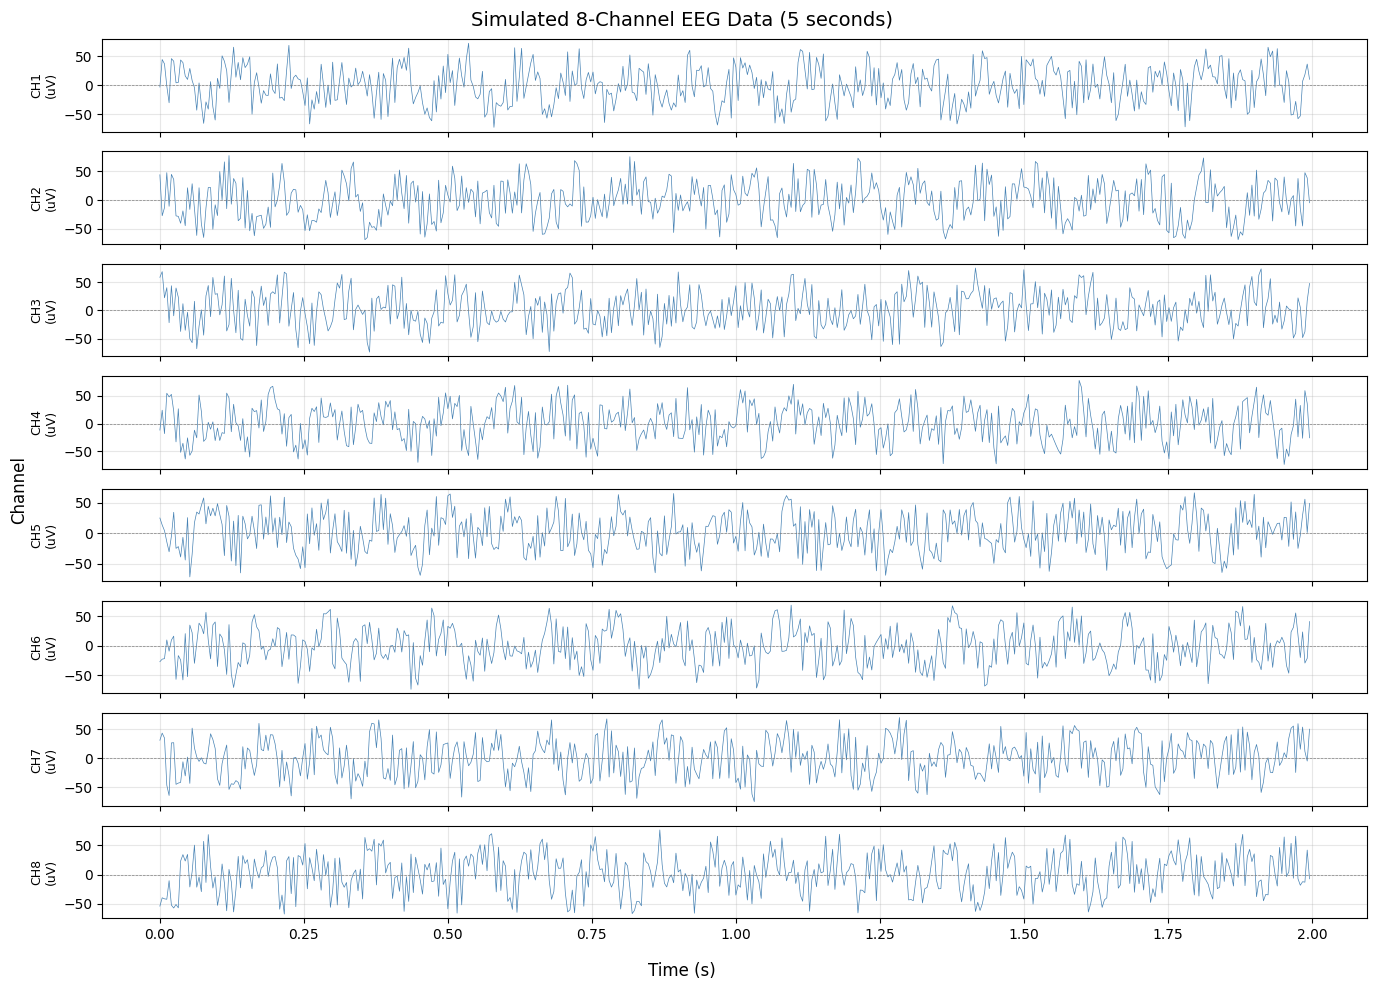

Data visualization complete.


In [72]:
import matplotlib.pyplot as plt

# 绘制多通道 EEG 波形
eeg_array, timestamps = collector.get_numpy_array()
print(eeg_array.shape)

fig, axes = plt.subplots(8, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Simulated 8-Channel EEG Data (5 seconds)', fontsize=14)

time_axis = np.arange(len(eeg_array)) / 250.0  # 转换为秒

for ch in range(8):
    axes[ch].plot(time_axis, eeg_array[:, ch], linewidth=0.5, color='steelblue')
    axes[ch].set_ylabel(f'CH{ch+1}\n(uV)', fontsize=9)
    axes[ch].grid(True, alpha=0.3)
    axes[ch].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

# 设置整个图表的共享 X 轴标签，显示时间单位为秒
fig.supxlabel("Time (s)")
fig.supylabel("Channel")
plt.tight_layout()
plt.show()
print("Data visualization complete.") 


## 7. 关键知识点总结

### 数据格式要点
1. **起始字节 `0xA0`**：用于数据包同步与验证
2. **24 位有符号 ADC**：需手动处理符号位扩展
3. **电压缩放**：取决于增益设置，增益越高，灵敏度越高
4. **采样序号循环**：0-255 循环，需处理溢出
5. **结束字节 `0xCX`**：携带数据包格式化信息

### 常见问题排查
- **起始字节非 0xA0**：数据流不同步，需重新同步或清空缓冲区
- **异常大的电压值**：可能是 24 位符号处理错误
- **电压漂移严重**：检查是否接触不良或电极阻抗过高

## 8. 练习任务

1. 修改 `parse_cyton_packet` 函数，使其支持 16 通道（Cyton + Daisy）模式
2. 实现一个滑动窗口数据缓存，只保留最近 N 秒的数据
3. 编写函数将 CSV 数据转换回原始数据包格式（反向编码）
4. 实现数据质量检查：标记信噪比过低的通道

---
*参考资料: [Cyton Data Format](https://docs.openbci.com/Cyton/CytonDataFormat/)*